# Week 2 — Tesla Deliveries: Regression & Forecasting Pipeline

**Objective:** Designed and implemented an end-to-end ML pipeline on sales/price data covering preprocessing, EDA, feature engineering, regression modeling, hyperparameter tuning, and time series forecasting.

### Step 1 : Data Loading & Initial Inspection
The dataset contains 2,640 rows and 12 columns covering monthly Tesla delivery records
from 2015–2025, broken out by Region and Model. .info() confirms data types (mostly
integers/floats with three categorical string columns)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("shape:", df.shape)
print("\ncolumns:", list(df.columns))
print("\ninfo()")
df.info()
print("\ndescribe()")
df.describe()

shape: (2640, 12)

columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  C

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


### Step 2 : Missing Values & Duplicate Rows
The dataset has zero missing values across all 12 columns and zero duplicate rows.
This means de-duplication is required before moving into EDA and feature
engineering the data is already clean and ready to use.

In [3]:
missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print("--- Missing values per column ---")
print(missing_values)
print("\nTotal missing values:", missing_values.sum())
print("Duplicate rows:", duplicate_rows)

--- Missing values per column ---
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Total missing values: 0
Duplicate rows: 0


In [4]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


### Step 3 : Exploratory Data Analysis
All five charts generate with titles and axis labels. along with **correlation heatmap**
shows Estimated_Deliveries and Production_Units are very strongly correlated
(r ≈ 0.99, well above the 0.9 threshold), which makes sense Tesla can only deliver what it produces.

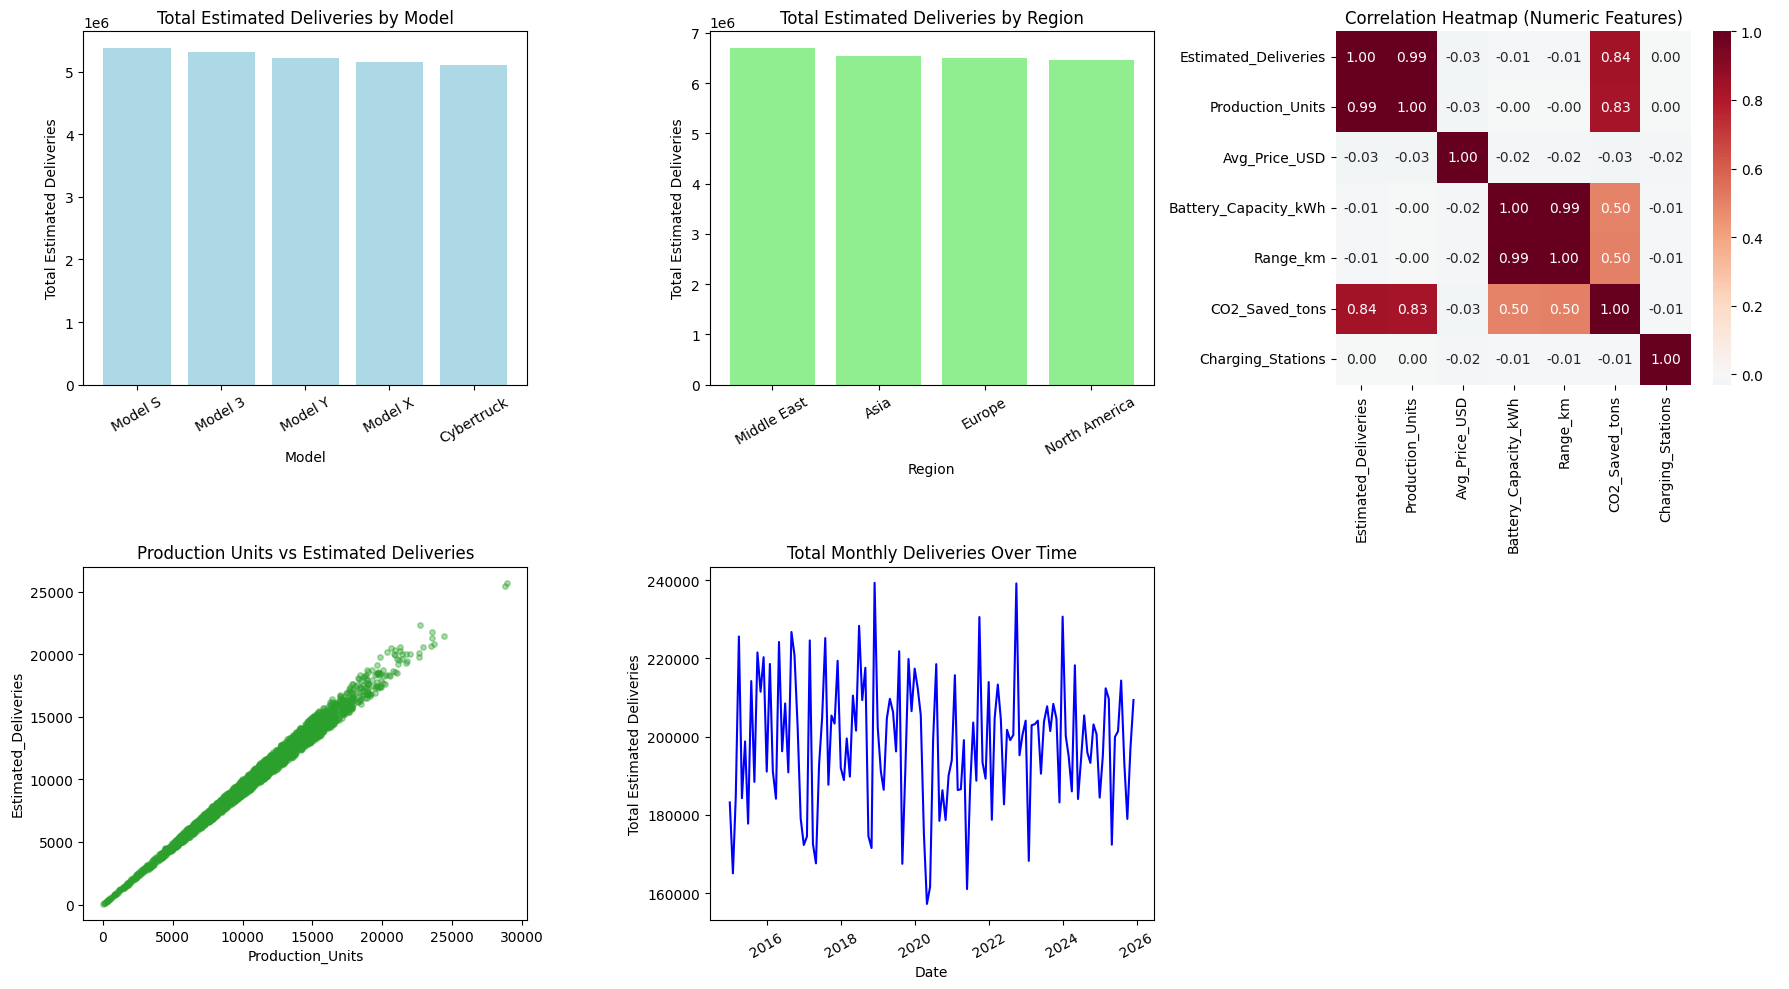

Production_Units <-> Estimated_Deliveries correlation: 0.9942


In [17]:
df = df.sort_values(["Year", "Month"]).reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

#1. Deliveries by Model
model_sales = df.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)
axes[0,0].bar(model_sales.index, model_sales.values, color="lightblue")
axes[0,0].set_title("Total Estimated Deliveries by Model")
axes[0,0].set_xlabel("Model")
axes[0,0].set_ylabel("Total Estimated Deliveries")
axes[0,0].tick_params(axis="x", rotation=30)

# 2. Deliveries by Region
region_sales = df.groupby("Region")["Estimated_Deliveries"].sum().sort_values(ascending=False)
axes[0,1].bar(region_sales.index, region_sales.values, color="lightgreen")
axes[0,1].set_title("Total Estimated Deliveries by Region")
axes[0,1].set_xlabel("Region")
axes[0,1].set_ylabel("Total Estimated Deliveries")
axes[0,1].tick_params(axis="x", rotation=30)

# 3. Correlation heatmap
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0,2])
axes[0,2].set_title("Correlation Heatmap (Numeric Features)")

# 4. Production vs Deliveries scatter
axes[1,0].scatter(df["Production_Units"], df["Estimated_Deliveries"], alpha=0.4, s=15, color="#2ca02c")
axes[1,0].set_title("Production Units vs Estimated Deliveries")
axes[1,0].set_xlabel("Production_Units")
axes[1,0].set_ylabel("Estimated_Deliveries")

# 5. Time-trend line (total deliveries per month across all regions/models)
monthly_total = df.groupby(["Year", "Month"])["Estimated_Deliveries"].sum().reset_index()
monthly_total["Date"] = pd.to_datetime(dict(year=monthly_total.Year, month=monthly_total.Month, day=1))
axes[1,1].plot(monthly_total["Date"], monthly_total["Estimated_Deliveries"], color="blue")
axes[1,1].set_title("Total Monthly Deliveries Over Time")
axes[1,1].set_xlabel("Date")
axes[1,1].set_ylabel("Total Estimated Deliveries")
axes[1,1].tick_params(axis="x", rotation=30)
axes[1,2].axis("off")  # unused subplot slot
plt.tight_layout()
plt.show()

print("Production_Units <-> Estimated_Deliveries correlation:",
      round(df["Production_Units"].corr(df["Estimated_Deliveries"]), 4))

### Step 4 : Encoding & Feature Engineering
The categorical columns (Region, Model, and Source_Type) are converted into numerical values using Label Encoding so that they can be used by machine learning algorithms. Two new features are then created to improve the model's ability to capture time-based patterns.The Deliveries_Lag1 feature stores the previous month's delivery count, while Rolling_Mean_3 calculates the average deliveries over the last three months  these operations create missing values at the beginning of the dataset, the missing values are replaced with the column mean. Finally, the dataset is checked to ensure that no missing values remain before proceeding to model training.


In [6]:
from sklearn.preprocessing import LabelEncoder

for col in ["Region", "Model", "Source_Type"]:
    le = LabelEncoder()
    df[col +"_enc"] = le.fit_transform(df[col])

# Lag feature: previous row's delivery count
df["Deliveries_Lag1"] = df["Estimated_Deliveries"].shift(1)
df["Deliveries_Lag1"] = df["Deliveries_Lag1"].fillna(df["Deliveries_Lag1"].mean())

# Rolling mean feature (trailing 3-period average)
df["Rolling_Mean_3"] = df["Estimated_Deliveries"].rolling(window=3).mean()
df["Rolling_Mean_3"] = df["Rolling_Mean_3"].fillna(df["Rolling_Mean_3"].mean())

print("Remaining NaNs in Deliveries_Lag1:",df["Deliveries_Lag1"].isna().sum())
print("Remaining NaNs in Rolling_Mean_3:",df["Rolling_Mean_3"].isna().sum())

df[["Region", "Region_enc", "Model", "Model_enc", "Source_Type", "Source_Type_enc",
    "Estimated_Deliveries", "Deliveries_Lag1", "Rolling_Mean_3"]].head()

Remaining NaNs in Deliveries_Lag1: 0
Remaining NaNs in Rolling_Mean_3: 0


,Region,Region_enc,Model,Model_enc,Source_Type,Source_Type_enc,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
0,Middle East,2,Model Y,4,Estimated (Region),0,10348,9921.649488,9921.864797
1,Asia,0,Model Y,4,Official (Quarter),2,12446,10348.000000,9921.864797
2,Europe,1,Model Y,4,Official (Quarter),2,10835,12446.000000,11209.666667
3,North America,3,Model X,3,Official (Quarter),2,8122,10835.000000,10467.666667
4,Middle East,2,Model S,2,Official (Quarter),2,13902,8122.000000,10953.000000


### Step 5 : Chronological Train/Test Split & Linear Regression
The dataset was divided into training and testing sets using an 80:20 chronological split to preserve the time order of the data. Eleven input features, including production units, vehicle specifications, encoded categorical variables, and engineered features (Deliveries_Lag1 and Rolling_Mean_3), were used to train a Linear Regression model. The model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. Finally, an Actual vs Predicted line plot was generated.


Train rows: 2112
Train rows: 80.0%
Test rows:  528
Test rows:  20.0%

Linear Regression - MAE: 317.51  RMSE: 386.23  R2: 0.9889


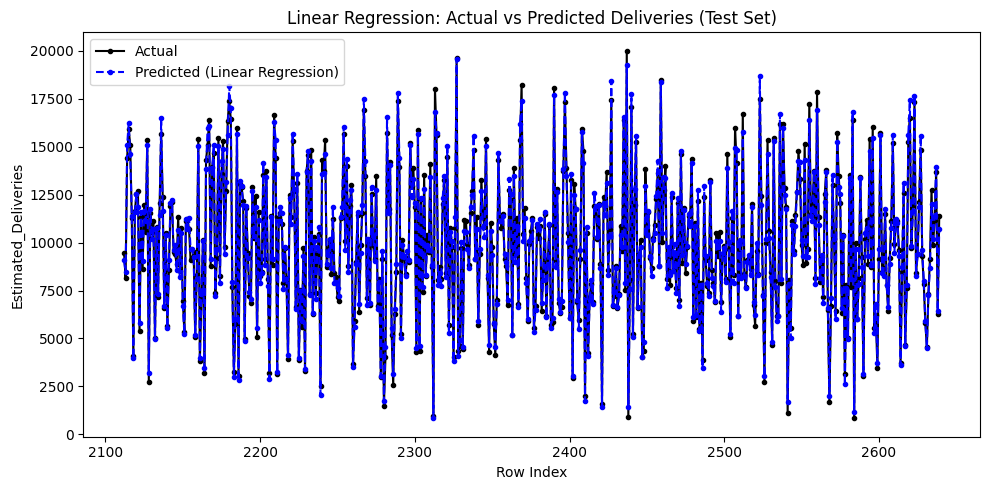

In [20]:
feature_cols = ["Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh", "Range_km","CO2_Saved_tons", "Charging_Stations", "Deliveries_Lag1", "Rolling_Mean_3",
                "Region_enc", "Model_enc", "Source_Type_enc"]
target_col = "Estimated_Deliveries"

# Chronological 80:20 split via index silcing (NOT train_test_split, because shuffling would leak future information into the training set)
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

X_train, y_train = train_df[feature_cols], train_df[target_col]
X_test, y_test = test_df[feature_cols], test_df[target_col]

print(f"Train rows: {len(X_train)}")
print(f"Train rows: {len(X_train)/len(df):.1%}")
print(f"Test rows:  {len(X_test)}")
print(f"Test rows:  {len(X_test)/len(df):.1%}")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)
print(f"\nLinear Regression - MAE: {lr_mae:.2f}  RMSE: {lr_rmse:.2f}  R2: {lr_r2:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(test_df.index, y_test.values, label="Actual", color="black", marker="o", markersize=3)
plt.plot(test_df.index, lr_preds, label="Predicted (Linear Regression)", color="Blue",
         linestyle="--", marker="o", markersize=3)
plt.title("Linear Regression: Actual vs Predicted Deliveries (Test Set)")
plt.xlabel("Row Index")
plt.ylabel("Estimated_Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

### Step 6 : 5-Fold Cross-Validation
Running 5-fold cross-validation on the Linear Regression model (with shuffle=False to
preserve chronological blocks) gives a per-fold R² for each of the 5 splits, along with the mean and standard deviation.

In [8]:
from sklearn.model_selection import KFold, cross_val_score
X_all, y_all = df[feature_cols], df[target_col]
kf = KFold(n_splits=5, shuffle=False)
cv_scores = cross_val_score(LinearRegression(), X_all, y_all, cv=kf, scoring="r2")

for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i} R2: {score:.4f}")

print(f"\nmean R2 across 5 folds: {cv_scores.mean():.4f}  (std:{cv_scores.std():.4f})")

Fold 1 R2: 0.9901
Fold 2 R2: 0.9911
Fold 3 R2: 0.9909
Fold 4 R2: 0.9906
Fold 5 R2: 0.9889

mean R2 across 5 folds: 0.9903  (std:0.0008)


### Step 7 : GridSearchCV & Random Forest
GridSearchCV tested different values of n_estimators (50, 100) and max_depth (5, 10, None), giving a total of 6 parameter combinations. Each combination was evaluated using 3-fold cross-validation to find the best settings for the Random Forest Regressor.
The feature importance graph also shows that Production_Units and the lag/rolling delivery features are the most important predictors, which matches the results found during the Exploratory Data Analysis (EDA).

Best parameters: {'max_depth': None, 'n_estimators': 100}
Best CV R2: 0.9887

Tuned Random Forest -> MAE: 329.62  RMSE: 408.78  R2: 0.9876


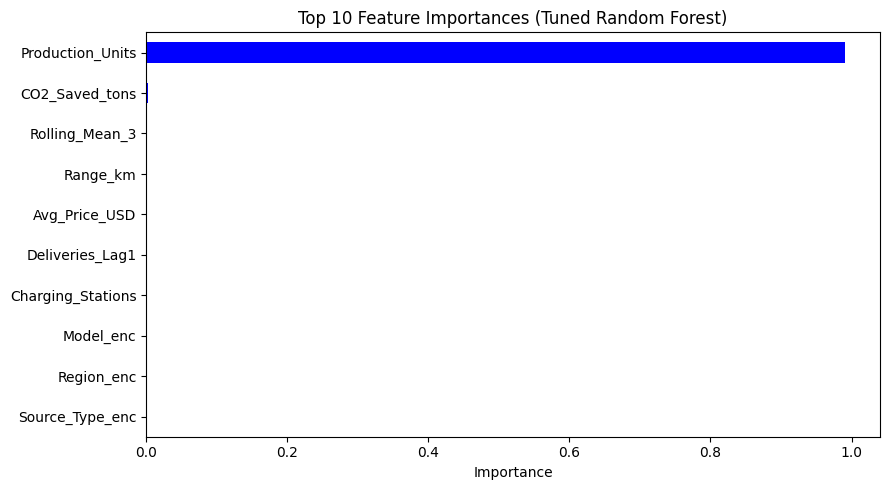

In [9]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [5, 10, None]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid,
                        cv=3, scoring="r2", n_jobs=1)
rf_grid.fit(X_train, y_train)
print("Best parameters:", rf_grid.best_params_)
print("Best CV R2:", round(rf_grid.best_score_, 4))

best_rf = rf_grid.best_estimator_
rf_preds = best_rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print(f"\nTuned Random Forest -> MAE: {rf_mae:.2f}  RMSE: {rf_rmse:.2f}  R2: {rf_r2:.4f}")

importances = pd.Series(best_rf.feature_importances_, index=feature_cols).sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 5))
importances.sort_values().plot(kind="barh", color="Blue")
plt.title("Top 10 Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

### Step 8 : ADF Stationarity Test
The augmented Dickey-Fuller test checks whether the Estimated Deliveries data is stationary
The p-value is much smaller than 0.05, so we conclude that the data is stationary. This means the delivery values do not show a continuous upward or downward trend and instead stay around a fairly constant level over the 2015–2025 period.

This matches the EDA time-series plot, which also showed stable delivery values over time. Since the target is stationary, it is well-suited for the regression models used in this project because the models do not need to predict a changing long-term trend.

In [10]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

if adf_result[1] < 0.05:
    print("\nConclusion: p-value < 0.05 -> reject the null hypothesis of a unit root.")
    print("The Estimated_Deliveries series is STATIONARY.")
else:
    print("\nConclusion: p-value >= 0.05 -> fail to reject the null hypothesis.")
    print("The Estimated_Deliveries series is NON-STATIONARY (likely has a trend/unit root).")

ADF Statistic: -24.662112249181465
p-value: 0.0
Critical Values:
1%: -3.4328
5%: -2.8626
10%: -2.5674

Conclusion: p-value < 0.05 -> reject the null hypothesis of a unit root.
The Estimated_Deliveries series is STATIONARY.


### Step 9 : Forecast Comparison Table
The table shows the actual delivery values and the predicted values for the first 20 test records using both Linear Regression and the tuned Random Forest models. It also includes the absolute percentage error for each prediction.

For most records, the predicted values are very close to the actual values, with only a small percentage of error. This shows that both models make accurate predictions, which is consistent with their high R² scores obtained during model evaluation.

In [11]:
n_show = 20
forecast_table = pd.DataFrame({
    "Actual": y_test.values[:n_show],
    "Predicted_LinearRegression": lr_preds[:n_show],
    "Predicted_RandomForest": rf_preds[:n_show]
})
forecast_table["Error_%_LR"] = (
    (forecast_table["Predicted_LinearRegression"] - forecast_table["Actual"]).abs()
    / forecast_table["Actual"] * 100
).round(2)
forecast_table["Error_%_RF"] = (
    (forecast_table["Predicted_RandomForest"] - forecast_table["Actual"]).abs()
    / forecast_table["Actual"] * 100
).round(2)

forecast_table

,Actual,Predicted_LinearRegression,Predicted_RandomForest,Error_%_LR,Error_%_RF
0,9476,9071.083085,9007.37,4.27,4.95
1,8179,8455.776325,8451.79,3.38,3.34
2,14430,15103.070929,15228.42,4.66,5.53
3,15912,16217.996293,15910.67,1.92,0.01
4,15077,14605.645363,14684.42,3.13,2.60
5,11280,11391.725690,11249.56,0.99,0.27
6,4070,3971.728693,4095.56,2.41,0.63
7,11636,11580.127472,11631.47,0.48,0.04
8,12540,12522.231135,12255.03,0.14,2.27
9,12717,11849.615292,11813.98,6.82,7.10


### Model Comparison Summary
Both Linear Regression and the tuned Random Forest performed very well, with R² scores above 0.95. However, Linear Regression performed slightly better, giving lower MAE, lower RMSE, and a slightly higher R² score.
This shows that a more complex model is not always the best choice.

In [12]:
comparison_table = pd.DataFrame({
    "Model":["Linear Regression", "Random Forest (tuned)"],
    "MAE": [round(lr_mae, 2), round(rf_mae, 2)],
    "RMSE": [round(lr_rmse, 2), round(rf_rmse, 2)],
    "R2": [round(lr_r2, 4), round(rf_r2, 4)]
})
comparison_table

,Model,MAE,RMSE,R2
0,Linear Regression,317.51,386.23,0.9889
1,Random Forest (tuned),329.62,408.78,0.9876
